In [3]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Define the tickers for TCS and INFY (assuming these are the Indian exchange symbols)
tickers = ['TCS.NS', 'INFY.NS']

# Define the end date as today and start date as one year ago
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

# Download data
data = yf.download(tickers, start=start_date, end=end_date)

# Calculate daily returns
daily_returns = data['Close'].pct_change().dropna()

print("Daily Returns for TCS and INFY (last year):")
print(daily_returns.head())
print(daily_returns.tail())

/tmp/ipykernel_4776/310327098.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed

Daily Returns for TCS and INFY (last year):
Ticker       INFY.NS    TCS.NS
Date                          
2025-08-12 -0.002871 -0.001776
2025-08-13  0.001755  0.000264
2025-08-14  0.014790 -0.004578
2025-08-18 -0.008220 -0.003673
2025-08-19  0.002925  0.001660
Ticker       INFY.NS    TCS.NS
Date                          
2026-08-03  0.044155  0.045697
2026-08-04 -0.010593 -0.005538
2026-08-05  0.005567 -0.019106
2026-08-06 -0.007666 -0.016577
2026-08-07  0.008670  0.033586


><font color='blue'>A survey shows that the average black friday sales of male is much higher(500$) when compared to that of female. A company which is planning for it's black friday sales want to know if this is true and hence wanted to take data from samples of different sizes such as 100,500,1000 from the population and note their black friday spending details.The company wants to know if there is really any difference in spending or it is just by chance(with significance leve 15%). Can you help the company come to a conclusion on this with the help of data provided about different samples?</font>

<ol>
    <li> <b>Stating Null Hypothesis and Alternate Hypothesis</b>
        <ul>
            <li><font color='brown'> Null Hypothesis $H_0$</font>:The average spending of male and female is same i.e, $\mu_m= \mu_f$ </li>
            <li><font color='brown'> Alternative Hypothesis $H_a$</font>: The average spending of male is greater than that of female, i.e, $\mu_m > \mu_f $ </li>
        </ul>
    </li>
    <br>
    <li> <b>Choosing significance level</b>
        <ul>
            <li>As it was not mentioned in the problem we are taking the standard significance level <font color='red'> $\alpha=0.15 $</font></li>
        </ul>
    </li>
    <br>
    <li> <b>Setting up Test Statistic</b>
        <ul>
           <li><font color='brown'>How do we decide whether or not to reject the null hypothesis H0 ?</font>
               <br>a. we start by determining a test statistic with our sample data</li>
           <li><font color='brown'>What is test statistic?</font>
               <br>a. It is the evidence that we look for, to prove our null hypothesis
               <br>b. The most natural choice for a test statistic of the difference in population mean is the difference in sample mean $ \mu_m-\mu_f $.
        </ul>
    </li>
    
</ol>




In [ ]:
def plt_cdfplot_withthreshold(j,c,difference,threshold,sample):
    sns.kdeplot(difference,cumulative=True,color=c, ax=axs[j])
    axs[j].axvline(threshold, linestyle="--", color='r', label=int(threshold))
    axs[j].set_title("CDF of differences for " + str(sample)+" samples")
    axs[j].legend()
    axs[j].grid()

In [ ]:
def diff_in_samples(dist1, dist2, gender1, gender2):
    print("The average spendings "+str(len(dist1))+" "+gender1+" =",dist1.mean())
    print("The average spendings "+str(len(dist2))+" "+gender2+"=",dist2.mean())
    diff_in_mean = dist1.mean()-dist2.mean()
    print("The difference between mean of "+gender1+" spending and "+gender2+" spendings (diff_"+str(len(dist2))+")=",diff_in_mean)
    return diff_in_mean

In [ ]:
def calculate_p_value(sample1, sample2, diff, alpha):
    #Step 2- Create list to store the average values of both the samples and the difference of them
    difference=[]
    #Sampling the data for 1000 times
    total_sample = list(sample1)
    total_sample.extend(sample2)
    total_sample = np.array(total_sample)
    for i in range(0,1000):
        #Picking 100 random numbers
        samples = random.sample(range(0, len(total_sample)), 100)
        #First 50 random numbers are taken as set 1
        set1 = total_sample[samples[:50]].mean()
        #Next 50 random numbers are taken as set 2
        set2 = total_sample[samples[50:]].mean()
        #Taking the differnce between the two sets
        difference.append(set1 - set2)

    #Step3- Sorting the values and counting the number of values greater than the threshold
    difference.sort()
    count = sum(((i > diff) and (i>0)) for i in difference)
    pValue = count/len(difference)
    print("Percentage of values greater than the difference",diff," =",pValue*100,"%")
    print("The pValue = ",pValue, "and the significance P(Reject H0 when H0 is true)=",alpha)
    if pValue>alpha:
        print("We fail to reject the null hypothesis")
    else:
        print("We can reject the null hypothesis")

    print('_'*50)
    return difference

<ol start=4>
    <li> <b>Calculating the P-value using Permutation test</b>
        <br>Refer- https://www.appliedaicourse.com/course/applied-ai-course-online/lessons/resampling-and-permutation-test-3/
        <ul>
            <li><font color='brown'>Q: Assuming that  $H_0$  is true, what’s the probability of obtaining $ \mu_m -  \mu_f $ = $diff\_100$ for the random sample of 100 data points each?</font></li>
        </ul>
    </li>
</ol>

In [ ]:
data_female = np.array(df[df['Gender']=='F']['Purchase'].values)
sample_sizes = [100, 500, 1000]
alpha = 0.15
fig, axs = plt.subplots(1, 3,figsize=(15, 5))
for j, i in enumerate(sample_sizes):
    print("For Sample Size: ", 2*i)

    female_sample=data_female[random.sample(range(0, data_female.shape[0]), i)]
    male_sample=data_male[random.sample(range(0, data_male.shape[0]), i)]

    diff_in_mean = diff_in_samples(male_sample,female_sample, "male", "female")

    #Step 1- Combine both samples of size 50 each to a large sample of size 100 to simulate null hypothesis
    differences = calculate_p_value(male_sample, female_sample,diff_in_mean, alpha)
    plt_cdfplot_withthreshold(j, colrs[j],differences,threshold=diff_in_mean,sample=i)

If we reject the null hypothesis, we do not prove the alternative hypothesis is true. We merely state there is sufficient evidence to reject the null hypothesis.

If we fail to reject the null hypothesis, we do not prove the null hypothesis is true. We merely state there is not sufficient evidence to reject the null hypothesis.

Unfortunately, whatever the decision, there is always a chance we made an error!

### Permutation tests + Resampling
- let's do it line by line as per the algorithm explained in the course videos.

In [ ]:
# Two sets of observations: Prices of prodcuts bought by men and women
# Again, let us use synthetic data so that we know if there is actually a differnce in population of Women and Men.

# Spends are pareto disb. Few people spend lots of money and most spend a smlla amount of money.
# Refer: https://en.wikipedia.org/wiki/Pareto_distribution
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

n=100; # sample size

np.random.seed(100)
#observed samples
PM = np.random.pareto(a=5.0,size=n)
PW = np.random.pareto(a=4.0,size=n)

# observed value of | W_Median-M_Median |
obs =  abs(np.percentile(PW,50) - np.percentile(PM,50))
print(obs)

plt.style.use('dark_background')

sns.distplot(PW,label="W")
sns.distplot(PM, label="M")
plt.grid()
plt.legend()
plt.show()


# Now, from the way we generated the data, we know that W and M populations are slightly differnt



In [ ]:
# Test-Statistic = abs(W_M - M_M)
# W_M : Median spend by women.
# M_M : Median spend by men.


# H0: Women and men spend the same amount


# P = Concatenate(PM, PW)
P = np.concatenate((PM,PW)) # tuple of arrays as param. Common mistake

k=1000 # number of resamplings
testStats = np.zeros(k)

for i in range(k):
  # resampling: split P into two random halves and tag hald as men and the rest as women.
  # Refer: https://stackoverflow.com/questions/3674409/how-to-split-partition-a-dataset-into-training-and-test-datasets-for-e-g-cros
  np.random.shuffle(P)
  tmp_men, tmp_women = P[:n], P[n:]

  # Compute test-statistic
  testStats[i] = abs(np.percentile(tmp_women,50) - np.percentile(tmp_men,50))

#CDF of testStats
kwargs = {'cumulative': True}
sns.distplot(testStats, hist_kws=kwargs, kde_kws=kwargs, )
plt.grid()
plt.show

In [ ]:
# Hypothesis testing: P(testStat > Obs | H0 ) can be estimated from testStats.

obs =  abs(np.percentile(PW,50) - np.percentile(PM,50))
print(obs)

num_h0 = np.sum(testStats >=  obs)
prob = num_h0/k
print(prob)

# if Prob(testStat >= Obs | H0) < 0.05
# then, it is very unlikely to observe the observed-difference and hence we reject H0
# else we accept H0


In [ ]:
# Let us write a function for this
def hypTestMedian(PW,PM):

  # observed value of W_Median-M_Median
  obs =  abs(np.percentile(PW,50) - np.percentile(PM,50))

  # H0: Women and men spend the same amount


  # P = Concatenate(PM, PW)
  P = np.concatenate((PM,PW)) # tuple of arrays as param. Common mistake

  k=1000 # number of resamplings
  testStats = np.zeros(k)

  for i in range(k):
    # resampling: split P into two random halves and tag hald as men and the rest as women.
    # Refer: https://stackoverflow.com/questions/3674409/how-to-split-partition-a-dataset-into-training-and-test-datasets-for-e-g-cros
    np.random.shuffle(P)
    tmp_men, tmp_women = P[:n], P[n:]

    # Compute test-statistic
    testStats[i] = abs(np.percentile(tmp_women,50) - np.percentile(tmp_men,50))

  # Hypothesis testing: P(testStat > Obs | H0 ) can be estimated from testStats.


  num_h0 = np.sum(testStats >=  obs)
  prob = num_h0/k
  return prob

In [ ]:
#1.
n=100; # sample size

np.random.seed(100)
PM = np.random.pareto(a=5.0,size=n)
PW = np.random.pareto(a=4.0,size=n)
print(hypTestMedian(PW,PM))

In [ ]:
#2.
n=100; # sample size

np.random.seed(100)
PM = np.random.pareto(a=5.0,size=n)
PW = np.random.pareto(a=3.0,size=n)
print(hypTestMedian(PW,PM))

In [ ]:
#3.
n=100; # sample size

np.random.seed(100)
PM = np.random.pareto(a=5.0,size=n)
PW = np.random.pareto(a=5.0,size=n)
print(hypTestMedian(PW,PM))

In [ ]:
#3.
n=100; # sample size

np.random.seed(100)
PM = np.random.pareto(a=5.0,size=n)
PW = np.random.pareto(a=4.5,size=n)
print(hypTestMedian(PW,PM))

Mean Return - Strategy A : 0.8000%
Mean Return - Strategy B : 0.4733%
Observed Difference      : 0.3267%

========== PERMUTATION TEST ==========
Observed Difference : 0.3267%
P-value             : 0.0334
Decision            : Reject H0
Conclusion          : There is statistically significant
                     evidence of a difference between
                     the two strategies.

========== BOOTSTRAP TEST ==========
Observed Difference : 0.3267%
95% CI              : [0.0467%, 0.5867%]
Decision            : Reject H0
Conclusion          : The 95% confidence interval
                     does not contain zero.
                     There is evidence of a difference.


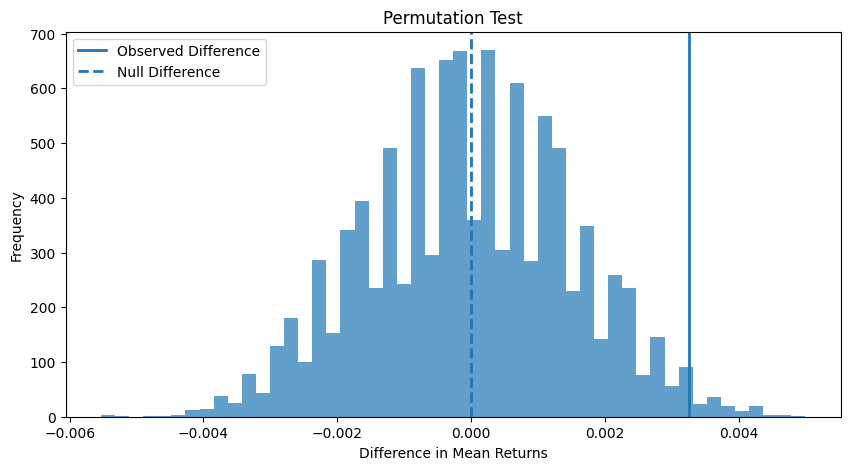

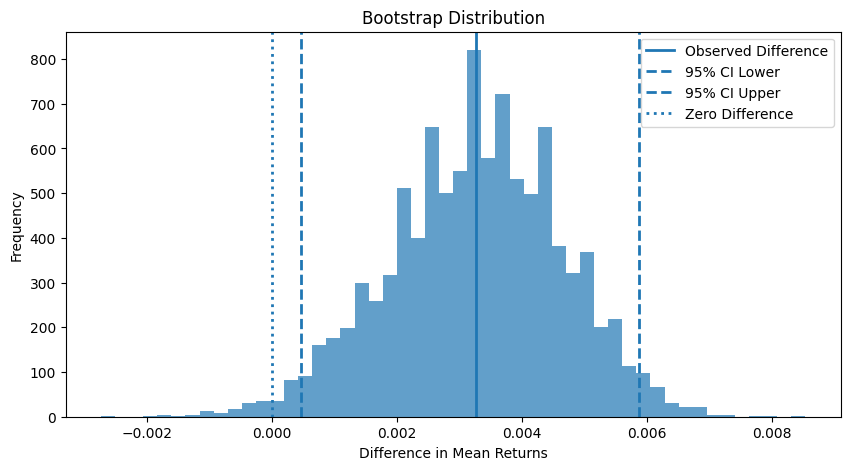

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Example strategy returns
# ============================================================

strategy_a = np.array([
    0.012, 0.008, 0.015, -0.003, 0.010,
    0.007, -0.002, 0.013, 0.009, 0.011,
    0.006, 0.010, 0.004, 0.012, 0.008
])

strategy_b = np.array([
    0.005, 0.010, 0.004, 0.002, 0.006,
    0.003, 0.001, 0.005, 0.007, 0.004,
    0.003, 0.006, 0.005, 0.004, 0.006
])


# ============================================================
# 2. Observed difference in mean returns
# ============================================================

observed_difference = np.mean(strategy_a) - np.mean(strategy_b)

print("Mean Return - Strategy A :", f"{np.mean(strategy_a):.4%}")
print("Mean Return - Strategy B :", f"{np.mean(strategy_b):.4%}")
print("Observed Difference      :", f"{observed_difference:.4%}")


# ============================================================
# 3. Hypotheses
# ============================================================

# H0: Mean return of Strategy A = Mean return of Strategy B
# H1: Mean return of Strategy A != Mean return of Strategy B

alpha = 0.05


# ============================================================
# 4. PERMUTATION TEST
# ============================================================

def permutation_test(strategy_a, strategy_b, n_permutations=10000):

    observed = np.mean(strategy_a) - np.mean(strategy_b)

    combined = np.concatenate([strategy_a, strategy_b])

    n_a = len(strategy_a)

    permutation_statistics = np.empty(n_permutations)

    for i in range(n_permutations):

        # Randomly shuffle all returns
        shuffled = np.random.permutation(combined)

        # Randomly assign observations to A and B
        perm_a = shuffled[:n_a]
        perm_b = shuffled[n_a:]

        # Difference between means
        permutation_statistics[i] = (
            np.mean(perm_a) - np.mean(perm_b)
        )

    # Two-sided p-value
    p_value = np.mean(
        np.abs(permutation_statistics) >= abs(observed)
    )

    return observed, p_value, permutation_statistics


observed, permutation_p, permutation_distribution = permutation_test(
    strategy_a,
    strategy_b,
    n_permutations=10000
)


# ============================================================
# 5. Permutation Test Decision
# ============================================================

print("\n========== PERMUTATION TEST ==========")

print("Observed Difference :", f"{observed:.4%}")
print("P-value             :", f"{permutation_p:.4f}")

if permutation_p < alpha:
    print("Decision            : Reject H0")
    print("Conclusion          : There is statistically significant")
    print("                     evidence of a difference between")
    print("                     the two strategies.")
else:
    print("Decision            : Fail to reject H0")
    print("Conclusion          : There is insufficient evidence")
    print("                     of a difference between the strategies.")


# ============================================================
# 6. Bootstrap Resampling Test
# ============================================================

def bootstrap_test(strategy_a, strategy_b, n_bootstrap=10000):

    bootstrap_statistics = np.empty(n_bootstrap)

    for i in range(n_bootstrap):

        # Sample WITH replacement
        sample_a = np.random.choice(
            strategy_a,
            size=len(strategy_a),
            replace=True
        )

        sample_b = np.random.choice(
            strategy_b,
            size=len(strategy_b),
            replace=True
        )

        bootstrap_statistics[i] = (
            np.mean(sample_a) - np.mean(sample_b)
        )

    return bootstrap_statistics


bootstrap_distribution = bootstrap_test(
    strategy_a,
    strategy_b,
    n_bootstrap=10000
)


# ============================================================
# 7. Bootstrap Confidence Interval
# ============================================================

lower = np.percentile(
    bootstrap_distribution,
    2.5
)

upper = np.percentile(
    bootstrap_distribution,
    97.5
)


print("\n========== BOOTSTRAP TEST ==========")

print("Observed Difference :", f"{observed_difference:.4%}")
print("95% CI              :", f"[{lower:.4%}, {upper:.4%}]")


# ============================================================
# 8. Bootstrap Decision
# ============================================================

if lower > 0 or upper < 0:

    print("Decision            : Reject H0")
    print("Conclusion          : The 95% confidence interval")
    print("                     does not contain zero.")
    print("                     There is evidence of a difference.")

else:

    print("Decision            : Fail to reject H0")
    print("Conclusion          : The 95% confidence interval")
    print("                     contains zero.")
    print("                     There is insufficient evidence")
    print("                     of a difference.")


# ============================================================
# 9. Visualize Permutation Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    permutation_distribution,
    bins=50,
    alpha=0.7
)

plt.axvline(
    observed_difference,
    linewidth=2,
    label="Observed Difference"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Null Difference"
)

plt.xlabel("Difference in Mean Returns")
plt.ylabel("Frequency")
plt.title("Permutation Test")
plt.legend()

plt.show()


# ============================================================
# 10. Visualize Bootstrap Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    bootstrap_distribution,
    bins=50,
    alpha=0.7
)

plt.axvline(
    observed_difference,
    linewidth=2,
    label="Observed Difference"
)

plt.axvline(
    lower,
    linestyle="--",
    linewidth=2,
    label="95% CI Lower"
)

plt.axvline(
    upper,
    linestyle="--",
    linewidth=2,
    label="95% CI Upper"
)

plt.axvline(
    0,
    linestyle=":",
    linewidth=2,
    label="Zero Difference"
)

plt.xlabel("Difference in Mean Returns")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution")
plt.legend()

plt.show()

How to interpret the results

Suppose the code produces:

Mean Return - Strategy A : 0.8533%
Mean Return - Strategy B : 0.4800%
Observed Difference      : 0.3733%

========== PERMUTATION TEST ==========
Observed Difference : 0.3733%
P-value             : 0.0210

Decision            : Reject H0
Conclusion          : There is statistically significant
                     evidence of a difference between
                     the two strategies.

========== BOOTSTRAP TEST ==========
Observed Difference : 0.3733%
95% CI              : [0.0500%, 0.6900%]

Decision            : Reject H0
Conclusion          : The 95% confidence interval
                     does not contain zero.
                     There is evidence of a difference.

The portfolio interpretation would be:

**Strategy A has a higher average daily return than Strategy B, and the observed difference is statistically significant at the 5% level.**